# CO2 Storage Modelling

#### [`neuralop`](https://github.com/neuraloperator/neuraloperator) FNO library.
Time-step and scalar parameters are embedded and concatenated as extra input channels;
the library FNO handles all spectral convolutions internally.

## Google Drive Mount

In [1]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT = "train_data_set"  # all 4500 files live here
CKPT_DIR = "/content/drive/MyDrive/checkpoints_fno"

import os

os.makedirs(CKPT_DIR, exist_ok=True)

DATA_DIR = os.path.join(DRIVE_ROOT, DATA_ROOT)
print("Data dir  :", DATA_DIR)
print("Checkpoint:", CKPT_DIR)

Mounted at /content/drive
Data dir  : /content/drive/MyDrive/train_data_set
Checkpoint: /content/drive/MyDrive/checkpoints_fno


## Imports & Device

In [2]:
import glob
import random
from dataclasses import dataclass
from typing import List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Constants

- `SINGLE_STEP = True` - model predicts 2 channels at one time index per forward pass. Not really worth setting to false as we lose the time embedding.

In [ ]:
NZ_MAX = 96
NX = 200
N_TIME = 24
N_SCALARS = (
    7  # inj_rate + temperature + depth + Swi + lam + perf_interval (2 perf interval)
)

SINGLE_STEP = True
OUT_CHANNELS = 2 if SINGLE_STEP else 2 * N_TIME

SPATIAL_IN_KEYS = ["porosity", "perm_r", "perm_z"]
SCALAR_KEYS = ["inj_rate", "temperature", "depth", "Swi", "lam", "perf_interval"]
TARGET_KEYS = ["pressure_buildup", "gas_saturation"]
IN_CHANNELS = len(SPATIAL_IN_KEYS)  # 3

TIME_LABELS = [
    "1 days",
    "2 days",
    "4 days",
    "7 days",
    "11 days",
    "17 days",
    "25 days",
    "37 days",
    "53 days",
    "77 days",
    "111 days",
    "158 days",
    "226 days",
    "323 days",
    "1.3 yr",
    "1.8 yr",
    "2.6 yr",
    "3.6 yr",
    "5.2 yr",
    "7.3 yr",
    "10.4 yr",
    "14.8 yr",
    "21.1 yr",
    "30.0 yr",
]

# FNO hyper-parameters
WIDTH = 32
N_MODES_Z = 16
N_MODES_X = 24
N_LAYERS = 4

BATCH_SIZE = 64  # increase from 16 - better GPU utilisation
N_VAL_STEPS = 6  # time steps sampled per batch during validation (instead of all 24)
SEED = 42
VAL_SIZE = 500

## File List & Train / Validation Split

All 4500 files are in one directory.  We split with a fixed seed so the same 500 files are always held out for validation. Normalisation statistics are computed after this split, on `train_files` only (avoid data leakage).

In [4]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))
assert len(all_files) > 0, f"No .npz files found in {DATA_DIR}"
print(f"Total files: {len(all_files)}")

rng = random.Random(SEED)
shuffled = all_files.copy()
rng.shuffle(shuffled)

val_files = shuffled[:VAL_SIZE]
train_files = shuffled[VAL_SIZE:]
print(f"Train: {len(train_files)}  |  Val: {len(val_files)}")

Total files: 4500
Train: 4000  |  Val: 500


## Quick Data Check

Full EDA is done separately. 

# We need to update this based on the outputs from Eduardo's EDA

In [5]:
with np.load(train_files[0]) as f:
    print("Keys :", list(f.keys()))
    for k, v in f.items():
        print(f"  {k:20s}  {str(np.asarray(v).shape):20s}  {np.asarray(v).dtype}")

Keys : ['porosity', 'perm_r', 'perm_z', 'inj_rate', 'temperature', 'depth', 'Swi', 'lam', 'perf_interval', 'pressure_buildup', 'gas_saturation']
  porosity              (93, 200)             float32
  perm_r                (93, 200)             float32
  perm_z                (93, 200)             float32
  inj_rate              ()                    float64
  temperature           ()                    float64
  depth                 ()                    float64
  Swi                   ()                    float64
  lam                   ()                    float64
  perf_interval         (2,)                  int64
  pressure_buildup      (93, 200, 24)         float32
  gas_saturation        (93, 200, 24)         float32


## Normalisation

We compute per-channel z-score statistics.

Val and tests sets to use the same statistical outcomes.

TODO: Apply log for permeabilities

In [6]:
LOG_KEYS = {"perm_r", "perm_z"}  # channels transformed to log-space before normalising


@dataclass
class NormStats:
    input_mean: np.ndarray  # (IN_CHANNELS,) = (3,)
    input_std: np.ndarray
    target_mean: np.ndarray  # (2,)
    target_std: np.ndarray
    scalar_mean: np.ndarray  # (N_SCALARS,)
    scalar_std: np.ndarray

    @classmethod
    def compute_from_files(
        cls, file_list: List[str], verbose: bool = True, n_sample: int = 1000
    ) -> "NormStats":
        """
        Random subsample of training files and accumulate (sum, sum-of-squares, count) per channel.
        Only valid (non-padded) cells are included.  Called ONCE on train_files; the result is applied
        to val and test unchanged.  Log-keys are transformed before accumulation so the resulting
        mean/std match what the dataset actually feeds to the model.
        """
        if len(file_list) > n_sample:
            rng_sample = random.Random(SEED)
            file_list = rng_sample.sample(file_list, n_sample)
        n = len(file_list)
        in_s = np.zeros(IN_CHANNELS, np.float64)
        in_s2 = np.zeros(IN_CHANNELS, np.float64)
        in_c = np.zeros(IN_CHANNELS, np.int64)

        tgt_s = np.zeros(2, np.float64)
        tgt_s2 = np.zeros(2, np.float64)
        tgt_c = np.zeros(2, np.int64)

        sc_rows = []

        for i, path in enumerate(file_list):
            if verbose and i % 200 == 0:
                print(f" {i}/{n} ...")
            with np.load(path) as f:
                nz = int(f["porosity"].shape[0])

                for c, key in enumerate(SPATIAL_IN_KEYS):
                    v = f[key][:nz, :].astype(np.float64).ravel()
                    if key in LOG_KEYS:
                        v = np.log(v)  # same transform as in __getitem__
                    in_s[c] += v.sum()
                    in_s2[c] += (v**2).sum()
                    in_c[c] += v.size

                for c, key in enumerate(TARGET_KEYS):
                    v = f[key][:nz, :, :].astype(np.float64).ravel()
                    tgt_s[c] += v.sum()
                    tgt_s2[c] += (v**2).sum()
                    tgt_c[c] += v.size

                parts = []
                for k in SCALAR_KEYS:
                    if k in f:
                        parts.append(np.asarray(f[k], np.float64).ravel())
                sc_rows.append(np.concatenate(parts))

        def _ms(s, s2, c):
            m = s / c
            std = np.sqrt(np.maximum(s2 / c - m**2, 0.0))
            return m.astype(np.float32), std.astype(np.float32)

        im, is_ = _ms(in_s, in_s2, in_c)
        tm, ts = _ms(tgt_s, tgt_s2, tgt_c)
        sc_arr = np.stack(sc_rows, axis=0)

        return cls(
            input_mean=im,
            input_std=is_,
            target_mean=tm,
            target_std=ts,
            scalar_mean=sc_arr.mean(0).astype(np.float32),
            scalar_std=sc_arr.std(0).astype(np.float32),
        )

    def norm_inputs(self, x: np.ndarray) -> np.ndarray:
        # x: (3, nz, 200): normalise before padding so padded zeros stay 0
        return (x - self.input_mean[:, None, None]) / (
            self.input_std[:, None, None] + 1e-8
        )

    def norm_targets(self, x: np.ndarray) -> np.ndarray:
        # x: (2, nz, 200, 24) or (2, nz, 200)
        m = self.target_mean
        s = self.target_std
        if x.ndim == 4:
            return (x - m[:, None, None, None]) / (s[:, None, None, None] + 1e-8)
        return (x - m[:, None, None]) / (s[:, None, None] + 1e-8)

    def norm_scalars(self, x: np.ndarray) -> np.ndarray:
        return (x - self.scalar_mean) / (self.scalar_std + 1e-8)

    def denorm_targets(self, x: torch.Tensor) -> torch.Tensor:
        m = torch.tensor(self.target_mean, dtype=x.dtype, device=x.device)
        s = torch.tensor(self.target_std, dtype=x.dtype, device=x.device)
        while m.dim() < x.dim():
            m = m.unsqueeze(-1)
            s = s.unsqueeze(-1)
        return x * (s + 1e-8) + m

In [7]:
import pickle

NORM_CACHE_PATH = os.path.join(CKPT_DIR, "norm_stats.pkl")
RECOMPUTE_NORM = False  # set True to force recomputation even if cache exists

print("Computing normalisation statistics on training set ...")
if not RECOMPUTE_NORM and os.path.exists(NORM_CACHE_PATH):
    print(f"Loading from cache: {NORM_CACHE_PATH}")
    with open(NORM_CACHE_PATH, "rb") as _f:
        norm_stats = pickle.load(_f)
else:
    norm_stats = NormStats.compute_from_files(train_files, verbose=True)
    with open(NORM_CACHE_PATH, "wb") as _f:
        pickle.dump(norm_stats, _f)
    print(f"Saved to: {NORM_CACHE_PATH}")

print("\nInput stats (mean | std):")
for key, m, s in zip(SPATIAL_IN_KEYS, norm_stats.input_mean, norm_stats.input_std):
    print(f"  {key:10s}  mean={m:.4f}  std={s:.4f}")
print("\nTarget stats (mean | std):")
for key, m, s in zip(TARGET_KEYS, norm_stats.target_mean, norm_stats.target_std):
    print(f"  {key:20s}  mean={m:.4f}  std={s:.4f}")
print("\nScalar stats (mean | std):")
for key, m, s in zip(SCALAR_KEYS, norm_stats.scalar_mean, norm_stats.scalar_std):
    print(f"  {key:15s}  mean={m:.4f}  std={s:.4f}")

Computing normalisation statistics on training set ...
 0/1000 ...
 200/1000 ...
 400/1000 ...
 600/1000 ...
 800/1000 ...
Saved to: /content/drive/MyDrive/checkpoints_fno/norm_stats.pkl

Input stats (mean | std):
  porosity    mean=0.1708  std=0.0370
  perm_r      mean=4.1529  std=2.1311
  perm_z      mean=0.1420  std=2.3493

Target stats (mean | std):
  pressure_buildup      mean=7.2746  std=23.9169
  gas_saturation        mean=0.0557  std=0.1657

Scalar stats (mean | std):
  inj_rate         mean=1.1095  std=0.5190
  temperature      mean=84.3081  std=30.6490
  depth            mean=202.3662  std=59.3305
  Swi              mean=0.2011  std=0.0579
  lam              mean=0.5090  std=0.1131
  perf_interval    mean=10.7610  std=13.7788


## Dataset

Key design choices:
- Normalisation is applied before zero-padding so padded rows remain exactly 0 in normalised space (rather than `(0 - mean)/std`).
- All 24 time steps are loaded and returned as `targets: (2, NZ_MAX, NX, N_TIME)`.

In [ ]:
class CO2FNODataset(Dataset):
    """
    Returns a dict:
      'inputs'  : (IN_CHANNELS,  NZ_MAX, NX)         normalised spatial inputs, zero-padded
      'targets' : (2,            NZ_MAX, NX, N_TIME)  normalised outputs, all 24 snapshots
      'scalars' : (N_SCALARS,)                        normalised scalar parameters
      'mask'    : (1,            NZ_MAX, NX)           1 = valid cell, 0 = padding
    """

    def __init__(self, file_list: List[str], norm_stats: NormStats):
        self.file_list = file_list
        self.ns = norm_stats

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        with np.load(path) as f:
            nz = int(f["porosity"].shape[0])

            # spatial inputs (nz, 200) each
            # need to convert 'perm_r' and 'perm_z' to log space before normalisation
            spatials = np.stack(
                [
                    (
                        np.log(f[k].astype(np.float32))
                        if k in ["perm_r", "perm_z"]
                        else f[k].astype(np.float32)
                    )
                    for k in SPATIAL_IN_KEYS
                ],
                axis=0,
            )  # (3, nz, 200)

            # all 24 time steps of both target fields
            targets = np.stack(
                [f[k].astype(np.float32) for k in TARGET_KEYS], axis=0
            )  # (2, nz, 200, 24)

            # scalar parameters
            sc_parts = [
                np.asarray(f[k], np.float32).ravel() for k in SCALAR_KEYS if k in f
            ]
            scalars = np.concatenate(sc_parts)  # (7,)

        spatials = self.ns.norm_inputs(spatials)  # (3, nz, 200)
        targets = self.ns.norm_targets(targets)  # (2, nz, 200, 24)
        scalars = self.ns.norm_scalars(scalars)  # (7,)

        # zero-pad to NZ_MAX
        mask = np.zeros((1, NZ_MAX, NX), np.float32)
        padded_in = np.zeros((IN_CHANNELS, NZ_MAX, NX), np.float32)
        padded_tgt = np.zeros((2, NZ_MAX, NX, N_TIME), np.float32)

        mask[0, :nz, :] = 1.0
        padded_in[:, :nz, :] = spatials
        padded_tgt[:, :nz, :, :] = targets

        return {
            "inputs": torch.from_numpy(padded_in),
            "targets": torch.from_numpy(padded_tgt),
            "scalars": torch.from_numpy(scalars),
            "mask": torch.from_numpy(mask),
        }

In [9]:
train_dataset = CO2FNODataset(train_files, norm_stats)
val_dataset = CO2FNODataset(val_files, norm_stats)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

batch = next(iter(train_loader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k:8s}: {tuple(v.shape)}")

Batch shapes:
  inputs  : (64, 3, 96, 200)
  targets : (64, 2, 96, 200, 24)
  scalars : (64, 7)
  mask    : (64, 1, 96, 200)


## Model

`CO2NeuralOpFNO` wraps `neuralop.FNO`, which only accepts a single input tensor. Conditioning is handled by embedding `time_idx` and `scalars` into 8-channel vectors, broadcasting them to the full spatial grid, and concatenating with the spatial inputs and mask before the FNO sees anything:

The git clone and pip install in the next cell only needs to run once per Colab session.

In [ ]:
# This is just taken from the deep learning notes.


class SinusoidalPositionEmbeddings(nn.Module):
    """Maps integer time indices 0‥N_TIME-1 to a dense vector of shape (B, dim)."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=device) / max(half - 1, 1)
        )
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)

In [11]:
def masked_mse(
    pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor
) -> torch.Tensor:
    """MSE averaged over valid (non-padded) cells only."""
    # pred, target: (B, C, H, W)  |  mask: (B, 1, H, W)
    n_valid = mask.sum() * pred.shape[1]
    return ((pred - target) ** 2 * mask).sum() / (
        n_valid + 1e-8
    )  # just multiply by mask to mute padded cells

This should only need to be run once but you might want to change the path

In [12]:
!git clone https://github.com/NeuralOperator/neuraloperator
NEURAL_OP_PATH = "/content/neuraloperator"

!cd neuraloperator && pip install -e . && pip install -r requirements.txt

Cloning into 'neuraloperator'...
remote: Enumerating objects: 15052, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 15052 (delta 169), reused 107 (delta 103), pack-reused 14811 (from 3)
Receiving objects: 100% (15052/15052), 118.54 MiB | 59.01 MiB/s, done.
Resolving deltas: 100% (9991/9991), done.
Obtaining file:///content/neuraloperator
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 86.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 7.8 MB/s eta 0:00:00
  Building editable for neuraloperator (pyproject.toml) ... done
  Created wheel for neuraloperator: filename=neuraloperator-2.0.0-0.ed

In [13]:
# In the above cell i have downlaoded the neural operator code from github and installed it
# the neuralop package needs to be added to the system path as it is differnet from running locally - again you might need to change the path

import sys

NEURAL_OP_PATH = "/content/neuraloperator"
if NEURAL_OP_PATH not in sys.path:
    sys.path.insert(0, NEURAL_OP_PATH)

from neuralop.models import FNO

/content/neuraloperator/neuralop/layers/discrete_continuous_convolution.py:114: SyntaxWarning: invalid escape sequence '\o'
  $T^{-1}_j \omega_i = T^{-1}_j T_i \nu$, but assumes a non-periodic subset of the
/content/neuraloperator/neuralop/models/rno.py:36: SyntaxWarning: invalid escape sequence '\h'
  \hat h_t = selu(W_h x_t + U_h (r_t * h_{t-1}) + b_h)


In [14]:
class CO2NeuralOpFNO(nn.Module):
    """
    Thin wrapper around neuralop.FNO that adds time and scalar conditioning.

    neuralop.FNO only accepts a single spatial tensor x.  We convert the
    conditioning signals into extra spatial channels by:
      - embedding time_idx  via SinusoidalPositionEmbeddings   (B, cond_channels)
      - embedding scalars   via a 2-layer MLP                  (B, cond_channels)
      - broadcasting both to (B, cond_channels, H, W) and concatenating with
        [spatial_cond | mask] before passing to the library FNO.

    Total input channels fed to neuralop.FNO:
        IN_CHANNELS(3) + mask(1) + time_embed(cond_channels) + scalar_embed(cond_channels)

    The forward signature is identical to CO2FNO so all training helpers
    (train_epoch, val_epoch, predict_all_timesteps) work unchanged.
    """

    def __init__(
        self,
        n_scalars: int = N_SCALARS,
        cond_channels: int = 8,
        n_modes: tuple = (N_MODES_Z, N_MODES_X),
        hidden_channels: int = WIDTH,
        n_layers: int = N_LAYERS,
    ):
        super().__init__()

        self.time_proj = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32, cond_channels),
        )

        self.scalar_proj = nn.Sequential(
            nn.Linear(n_scalars, cond_channels),
            nn.SiLU(),
            nn.Linear(cond_channels, cond_channels),
        )

        fno_in = IN_CHANNELS + 1 + 2 * cond_channels  # 3 + 1 + 8 + 8 = 20

        self.fno = FNO(
            n_modes=list(n_modes),
            in_channels=fno_in,
            out_channels=OUT_CHANNELS,
            hidden_channels=hidden_channels,
            n_layers=n_layers,
            positional_embedding=None,
        )

    def forward(
        self,
        spatial_cond: torch.Tensor,
        scalars: torch.Tensor,
        time_idx: torch.Tensor,
        mask: torch.Tensor,
    ) -> torch.Tensor:

        B, _, H, W = spatial_cond.shape

        t_emb = self.time_proj(time_idx)[:, :, None, None].expand(B, -1, H, W)
        s_emb = self.scalar_proj(scalars)[:, :, None, None].expand(B, -1, H, W)

        x = torch.cat([spatial_cond, mask, t_emb, s_emb], dim=1)

        # error workaround - force float32
        with torch.autocast(device_type=x.device.type, enabled=False):
            out = self.fno(x.float())

        return out * mask

In [19]:
use_amp = (
    False  # FNO spectral weights are ComplexFloat - line added to circumvent error
)
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        inp = batch["inputs"].to(DEVICE, non_blocking=True)
        sc = batch["scalars"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)
        B = inp.shape[0]

        t_idx = random.randint(0, N_TIME - 1)
        # slice on CPU before transfer - avoids moving the full 24-step tensor to GPU
        tgt_t = batch["targets"][:, :, :, :, t_idx].to(DEVICE, non_blocking=True)
        t_vec = torch.full((B,), t_idx, dtype=torch.long, device=DEVICE)

        with torch.autocast(
            device_type=DEVICE.type, enabled=use_amp
        ):  # use amp set to false to prevent error
            loss = masked_mse(model(inp, sc, t_vec, mask), tgt_t, mask)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * B

    return total / len(loader.dataset)


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total = 0.0
    # sample N_VAL_STEPS time indices once per epoch
    t_steps = random.sample(range(N_TIME), N_VAL_STEPS)
    for batch in loader:
        inp = batch["inputs"].to(DEVICE, non_blocking=True)
        sc = batch["scalars"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)
        B = inp.shape[0]

        step_losses = []
        for t in t_steps:
            tgt_t = batch["targets"][:, :, :, :, t].to(DEVICE, non_blocking=True)
            t_vec = torch.full((B,), t, dtype=torch.long, device=DEVICE)
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                step_losses.append(
                    masked_mse(model(inp, sc, t_vec, mask), tgt_t, mask).item()
                )
        total += np.mean(step_losses) * B

    return total / len(loader.dataset)


@torch.no_grad()
def predict_all_timesteps(model, inp, sc, mask):
    """Return predictions for all N_TIME steps: (B, 2, NZ_MAX, NX, N_TIME)."""
    model.eval()
    B = inp.shape[0]
    preds = torch.zeros(B, 2, NZ_MAX, NX, N_TIME, device=inp.device)
    for t in range(N_TIME):
        t_vec = torch.full((B,), t, device=inp.device, dtype=torch.long)
        with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
            preds[..., t] = model(inp, sc, t_vec, mask)
    return preds * mask.unsqueeze(-1)

/tmp/ipykernel_1503/1226582286.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)


## Overfitting Test & Training

Output shape: (8, 2, 96, 200)
Trainable parameters: 866,674
  Step  50/200  loss: 1.609292
  Step 100/200  loss: 0.291753
  Step 150/200  loss: 0.182550
  Step 200/200  loss: 0.155228


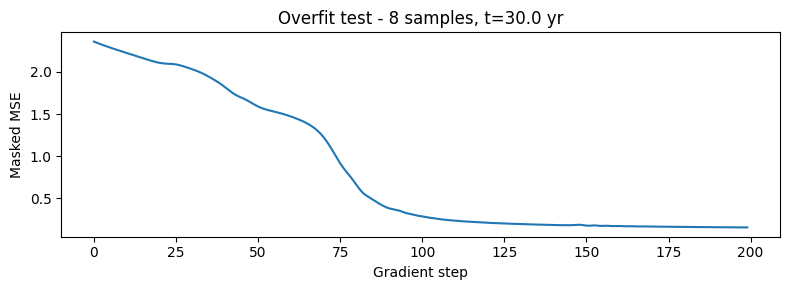

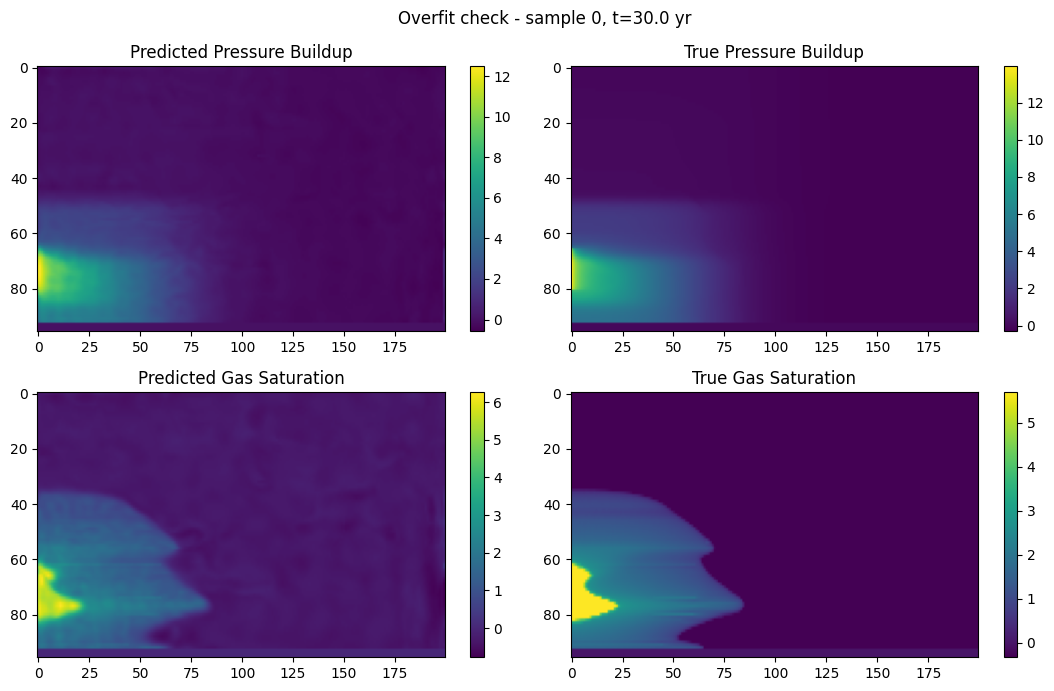

In [17]:
N_OV = 8
OV_STEPS = 200
OV_T_IDX = N_TIME - 1  # 30-yr snapshot

ov_dataset = CO2FNODataset(train_files[:N_OV], norm_stats)
ov_loader = DataLoader(ov_dataset, batch_size=N_OV, shuffle=False)
ov_batch = next(iter(ov_loader))
ov_inp = ov_batch["inputs"].to(DEVICE)
ov_tgt_all = ov_batch["targets"].to(DEVICE)
ov_sc = ov_batch["scalars"].to(DEVICE)
ov_mask = ov_batch["mask"].to(DEVICE)
ov_tgt = ov_tgt_all[:, :, :, :, OV_T_IDX]
ov_t_vec = torch.full((N_OV,), OV_T_IDX, device=DEVICE, dtype=torch.long)

# Sanity check - forward pass shape
nop_model = CO2NeuralOpFNO().to(DEVICE)
with torch.no_grad():
    _out = nop_model(ov_inp, ov_sc, ov_t_vec, ov_mask)
print("Output shape:", tuple(_out.shape))  # expect (8, 2, 96, 200)
n_params = sum(p.numel() for p in nop_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# Overfit on 8 samples - loss should fall toward zero
model_ov = CO2NeuralOpFNO().to(DEVICE)
opt_ov = optim.Adam(model_ov.parameters(), lr=1e-3)
ov_losses = []
model_ov.train()
for step in range(OV_STEPS):
    loss = masked_mse(model_ov(ov_inp, ov_sc, ov_t_vec, ov_mask), ov_tgt, ov_mask)
    opt_ov.zero_grad()
    loss.backward()
    opt_ov.step()
    ov_losses.append(loss.item())
    if (step + 1) % 50 == 0:
        print(f"  Step {step+1:3d}/{OV_STEPS}  loss: {loss.item():.6f}")

plt.figure(figsize=(8, 3))
plt.plot(ov_losses)
plt.xlabel("Gradient step")
plt.ylabel("Masked MSE")
plt.title(f"Overfit test - {N_OV} samples, t={TIME_LABELS[OV_T_IDX]}")
plt.tight_layout()
plt.show()

model_ov.eval()
with torch.no_grad():
    pred_ov = model_ov(ov_inp, ov_sc, ov_t_vec, ov_mask).cpu()
tgt_cpu = ov_tgt.cpu()
mask_cpu = ov_mask.cpu()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, (name, ch) in enumerate([("Pressure Buildup", 0), ("Gas Saturation", 1)]):
    im0 = axes[row, 0].imshow(
        pred_ov[0, ch] * mask_cpu[0, 0], aspect="auto", origin="upper"
    )
    im1 = axes[row, 1].imshow(tgt_cpu[0, ch], aspect="auto", origin="upper")
    axes[row, 0].set_title(f"Predicted {name}")
    axes[row, 1].set_title(f"True {name}")
    plt.colorbar(im0, ax=axes[row, 0])
    plt.colorbar(im1, ax=axes[row, 1])
plt.suptitle(f"Overfit check, t={TIME_LABELS[OV_T_IDX]}")
plt.tight_layout()
plt.show()

Starting training ...
Epoch   1/100  train: 1.213374  val: 0.739328  lr: 1.00e-03
  new best val: 0.739328
Epoch   2/100  train: 0.896862  val: 0.820099  lr: 1.00e-03
Epoch   3/100  train: 0.894391  val: 1.052940  lr: 1.00e-03
Epoch   4/100  train: 0.903428  val: 0.941953  lr: 1.00e-03
Epoch   5/100  train: 0.716432  val: 0.569087  lr: 1.00e-03
  new best val: 0.569087
Epoch   6/100  train: 0.572206  val: 0.722083  lr: 1.00e-03
Epoch   7/100  train: 0.605059  val: 0.502604  lr: 1.00e-03
  new best val: 0.502604
Epoch   8/100  train: 0.452180  val: 0.457675  lr: 1.00e-03
  new best val: 0.457675
Epoch   9/100  train: 0.415654  val: 0.486286  lr: 1.00e-03
Epoch  10/100  train: 0.480089  val: 0.544303  lr: 1.00e-03
Epoch  11/100  train: 0.372512  val: 0.479964  lr: 1.00e-03
Epoch  12/100  train: 0.352564  val: 0.373974  lr: 1.00e-03
  new best val: 0.373974
Epoch  13/100  train: 0.333866  val: 0.448714  lr: 1.00e-03
Epoch  14/100  train: 0.319370  val: 0.479354  lr: 1.00e-03
Epoch  15/100

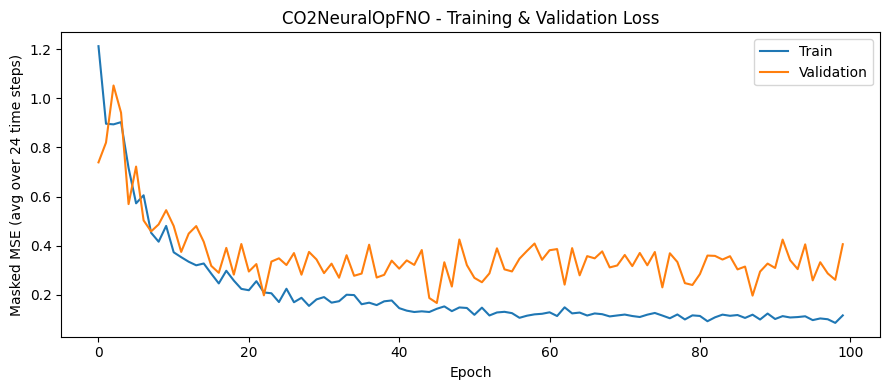

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch._C._nn.gelu was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch._C._nn.gelu])` or the `torch.serialization.safe_globals([torch._C._nn.gelu])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default

In [ ]:
torch.backends.cudnn.benchmark = True  # auto-tunes kernels for fixed input sizes

NUM_EPOCHS = 50
NOP_CKPT_PATH = os.path.join(CKPT_DIR, "co2_nop_fno.pth")
NOP_BEST_PATH = os.path.join(CKPT_DIR, "co2_nop_fno_best.pth")

nop_model = CO2NeuralOpFNO().to(DEVICE)
nop_optimizer = optim.Adam(nop_model.parameters(), lr=1e-3)
nop_scheduler = optim.lr_scheduler.StepLR(nop_optimizer, step_size=20, gamma=0.5)

nop_train_losses, nop_val_losses = [], []
nop_best_val = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == 1:
        print("Starting training ...")
    train_loss = train_epoch(nop_model, train_loader, nop_optimizer)
    val_loss = val_epoch(nop_model, val_loader)
    nop_scheduler.step()
    nop_train_losses.append(train_loss)
    nop_val_losses.append(val_loss)
    print(
        f"Epoch {epoch:3d}/{NUM_EPOCHS}  train: {train_loss:.6f}  val: {val_loss:.6f}"
        f"  lr: {nop_scheduler.get_last_lr()[0]:.2e}"
    )
    torch.save(
        {
            "model": nop_model.state_dict(),
            "opt": nop_optimizer.state_dict(),
            "sched": nop_scheduler.state_dict(),
            "epoch": epoch,
            "train_losses": nop_train_losses,
            "val_losses": nop_val_losses,
        },
        NOP_CKPT_PATH,
    )
    if val_loss < nop_best_val:
        nop_best_val = val_loss
        torch.save(
            {"model": nop_model.state_dict(), "epoch": epoch, "best_val": nop_best_val},
            NOP_BEST_PATH,
        )
        print(f"  new best val: {nop_best_val:.6f}")

plt.figure(figsize=(9, 4))
plt.plot(nop_train_losses, label="Train")
plt.plot(nop_val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE (avg over 24 time steps)")
plt.title("CO2NeuralOpFNO - Training & Validation Loss")
plt.savefig(os.path.join(CKPT_DIR, "co2_nop_fno_loss.png"))
plt.legend()
plt.tight_layout()
plt.show()

Best checkpoint: epoch 46  val=0.165634


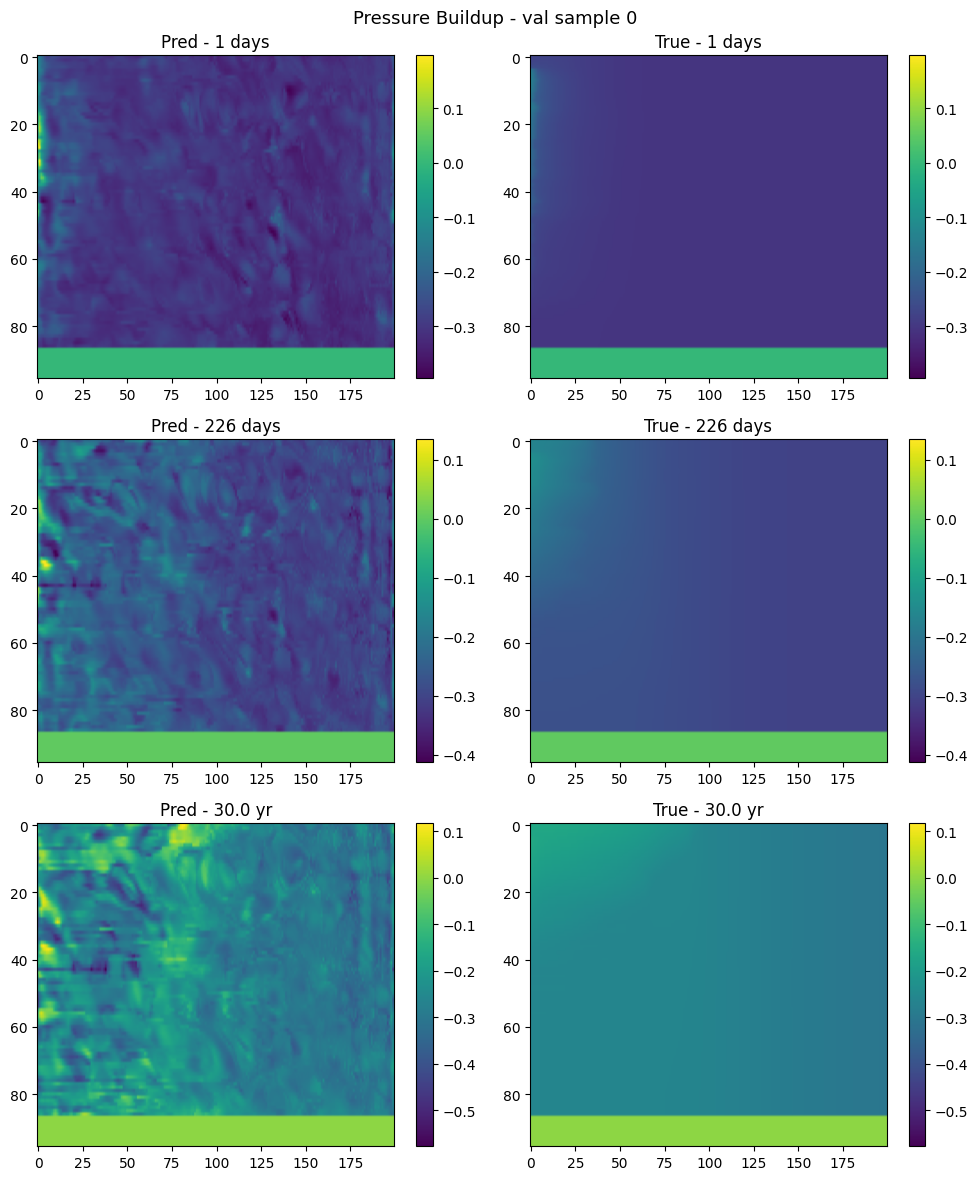

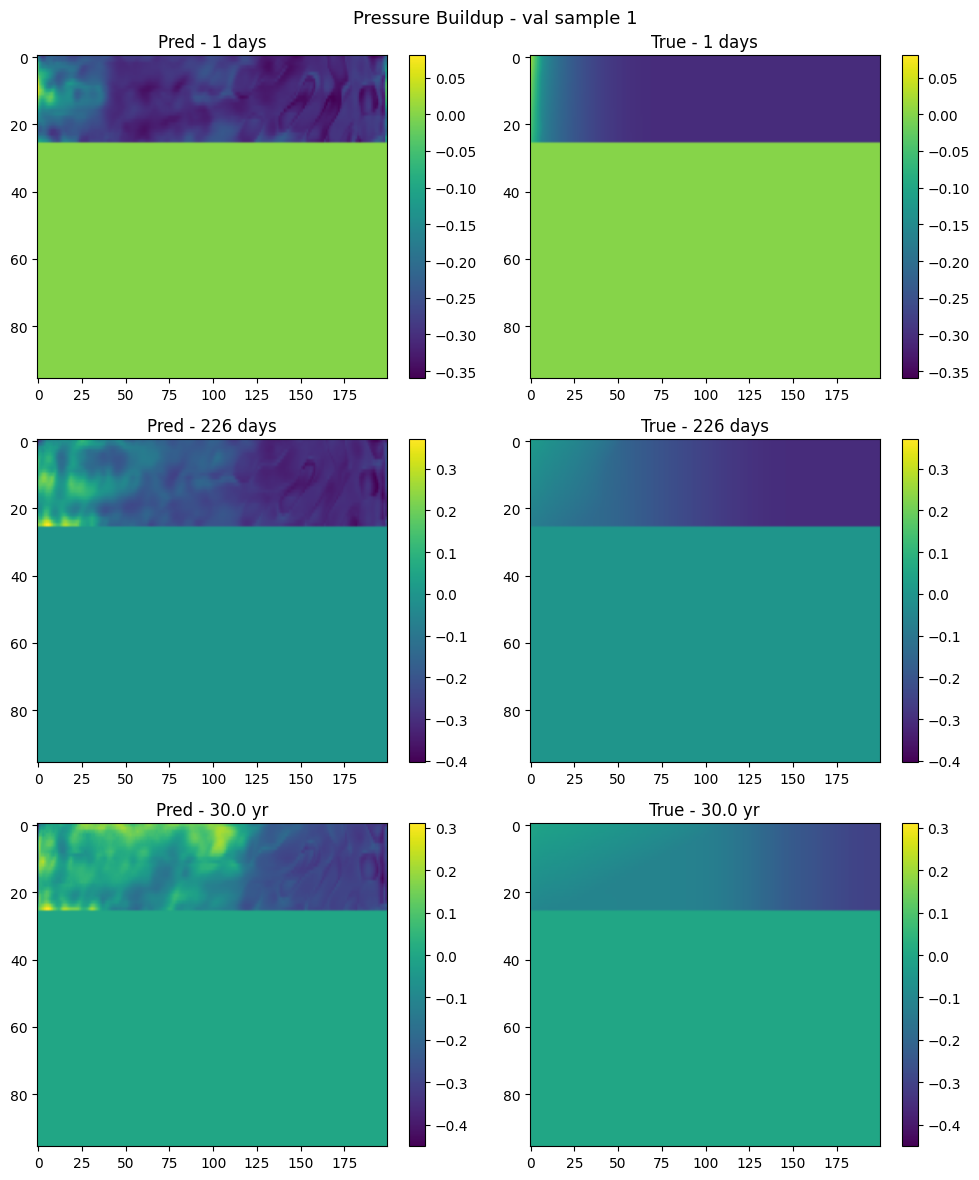

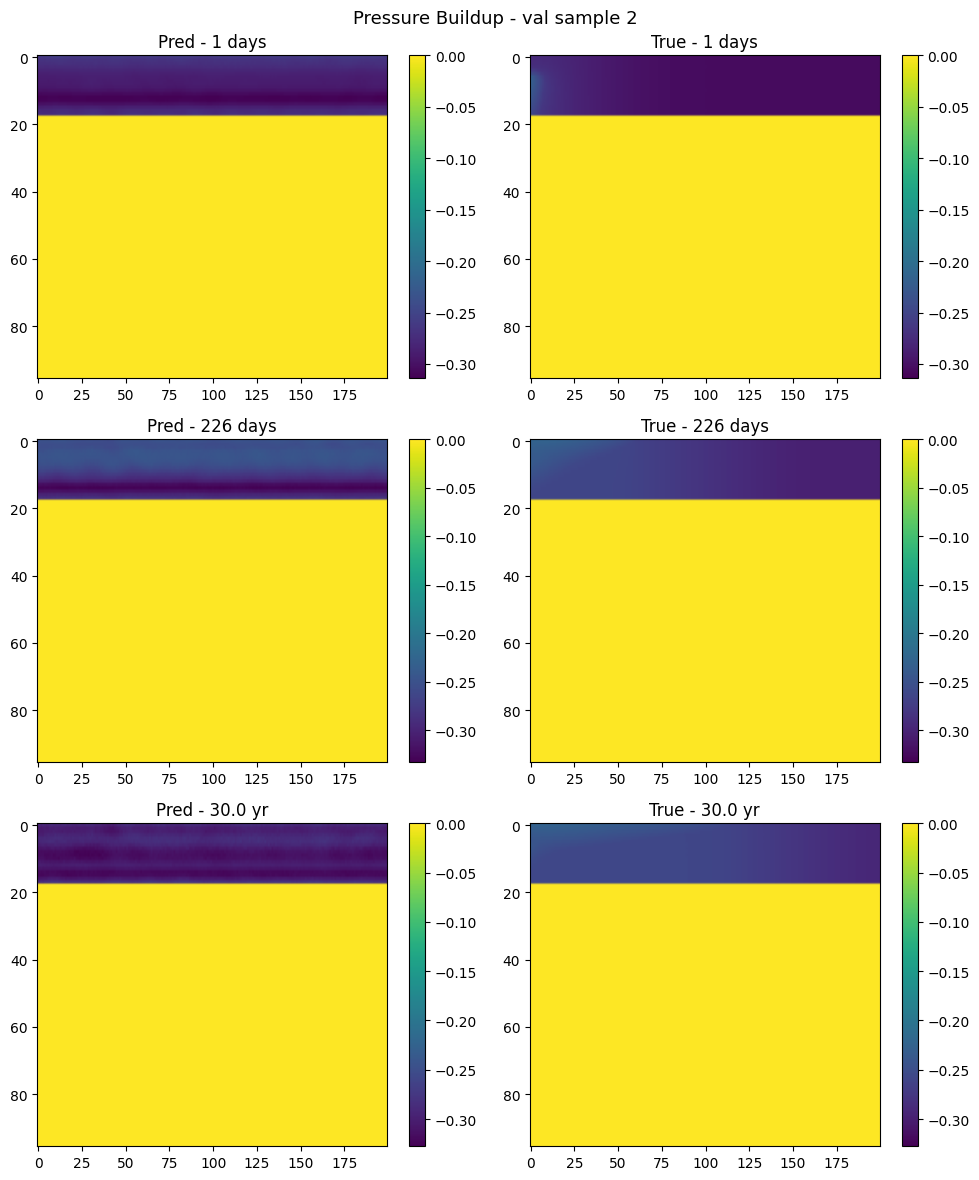

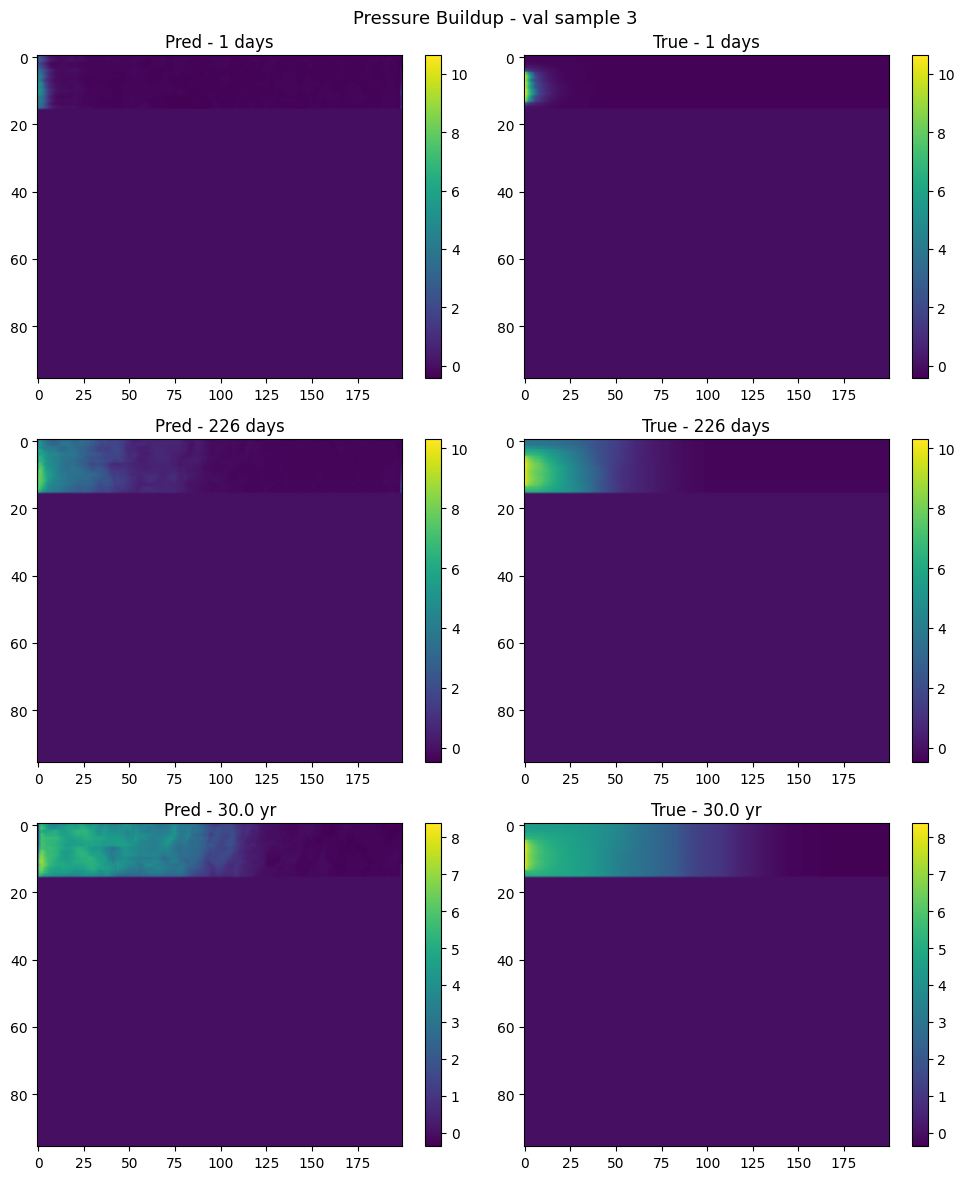

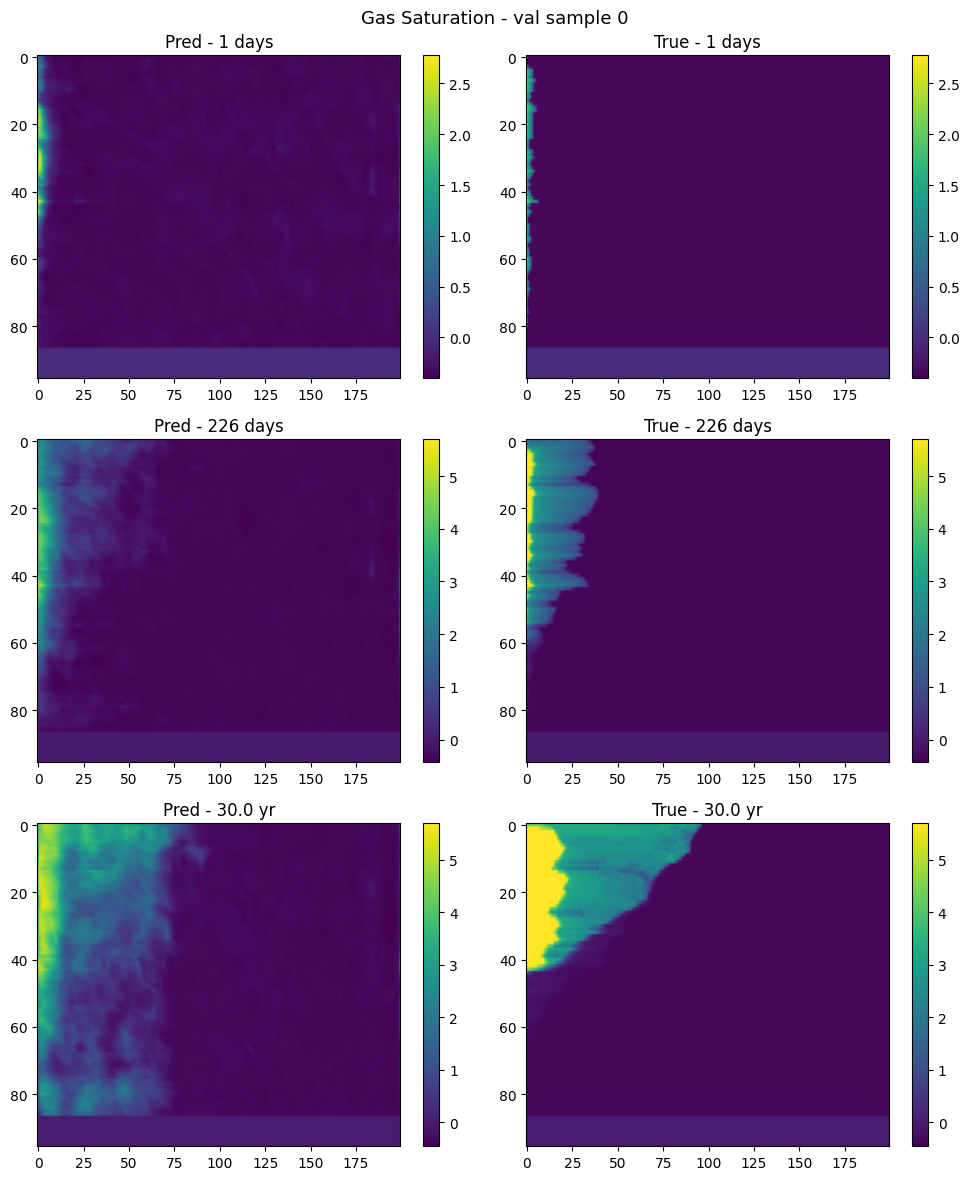

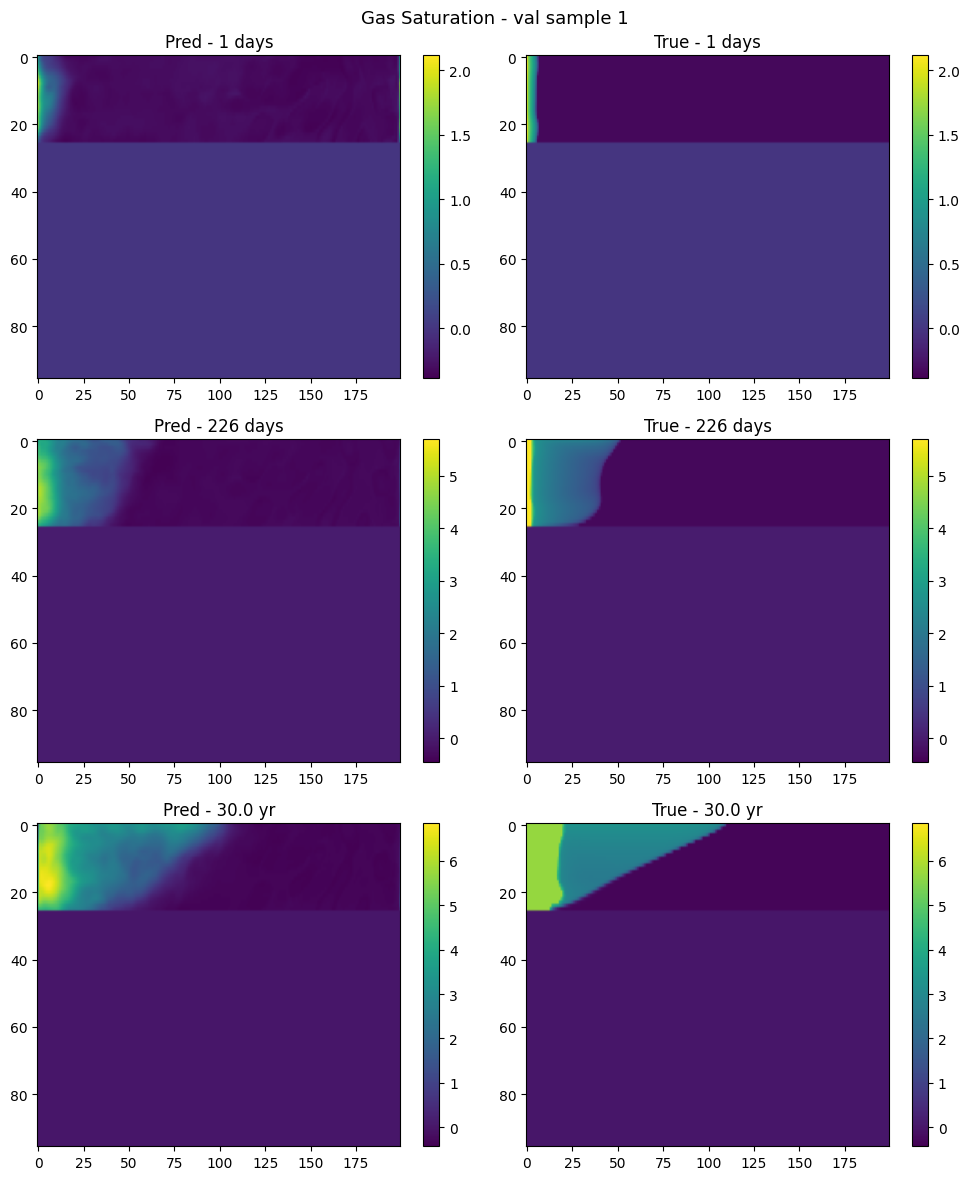

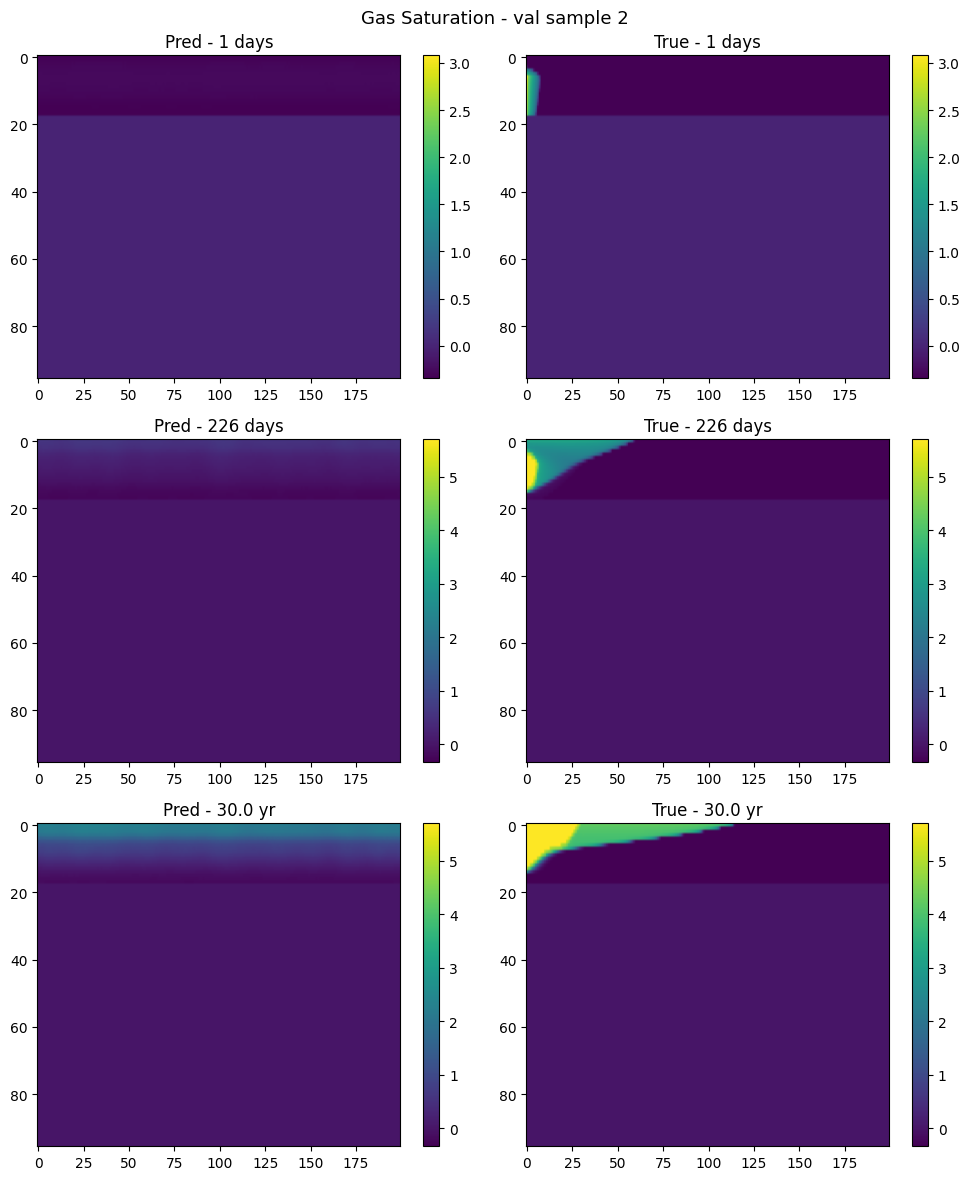

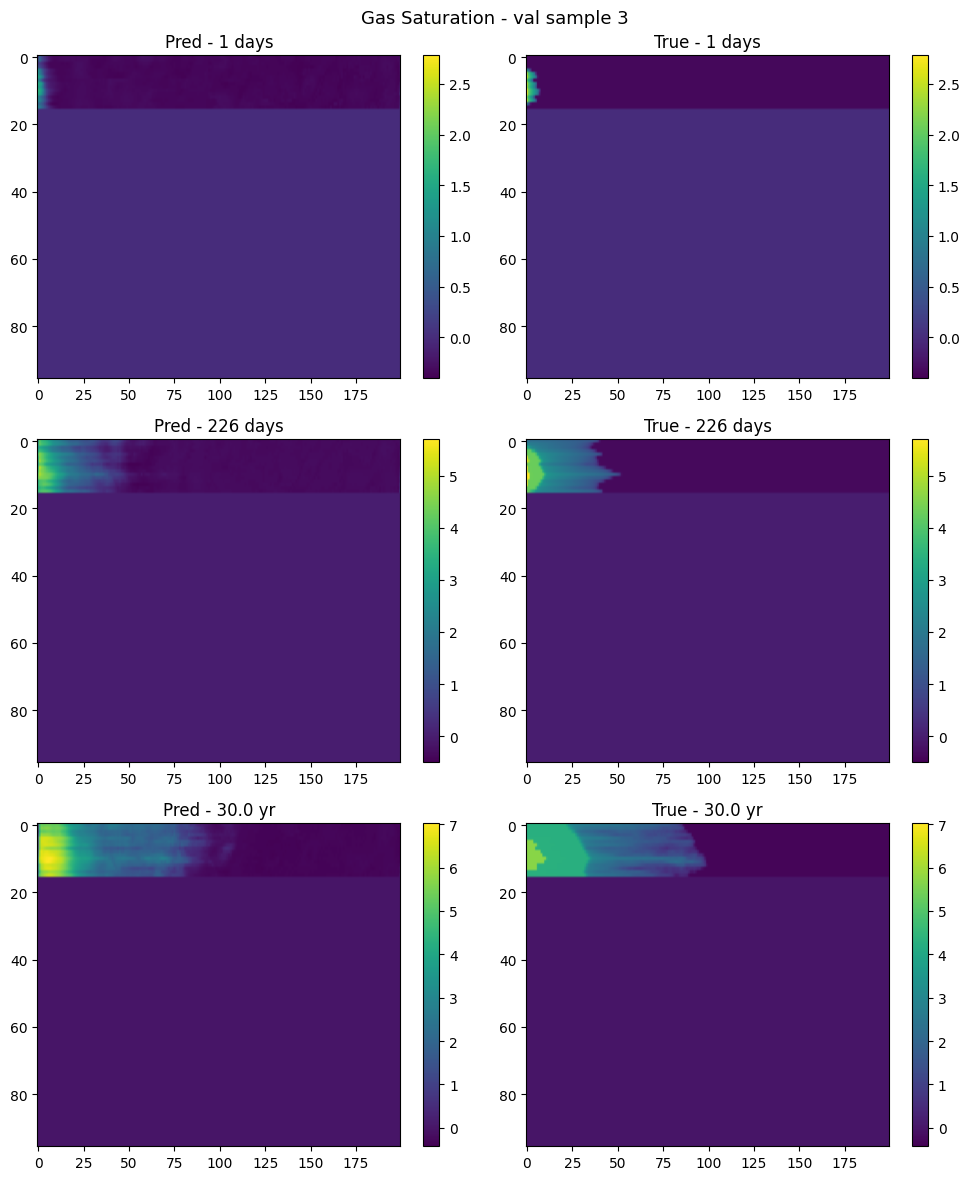

In [ ]:
# Evaluation
ckpt = torch.load(NOP_BEST_PATH, map_location=DEVICE, weights_only=False)
state = ckpt["model"]
state.pop("_metadata", None)  # fix to prevent key error
nop_model.load_state_dict(state)
print(f"Best checkpoint: epoch {ckpt['epoch']}  val={ckpt['best_val']:.6f}")

val_batch = next(iter(val_loader))
v_inp = val_batch["inputs"].to(DEVICE)
v_tgt = val_batch["targets"].to(DEVICE)
v_sc = val_batch["scalars"].to(DEVICE)
v_mask = val_batch["mask"].to(DEVICE)

preds = predict_all_timesteps(nop_model, v_inp, v_sc, v_mask).cpu()
v_tgt_cpu = v_tgt.cpu()
v_mask_cpu = v_mask.cpu()

SHOW_STEPS = [0, 12, 23]
N_SHOW_SAMPLES = 4
for v_ch, v_name in enumerate(["Pressure Buildup", "Gas Saturation"]):
    for s in range(N_SHOW_SAMPLES):
        fig, axes = plt.subplots(len(SHOW_STEPS), 2, figsize=(10, 4 * len(SHOW_STEPS)))
        for row, t in enumerate(SHOW_STEPS):
            p = (preds[s, v_ch, :, :, t] * v_mask_cpu[s, 0]).numpy()
            g = v_tgt_cpu[s, v_ch, :, :, t].numpy()
            vmin, vmax = min(p.min(), g.min()), max(p.max(), g.max())
            im0 = axes[row, 0].imshow(p, aspect="auto", vmin=vmin, vmax=vmax)
            im = axes[row, 1].imshow(g, aspect="auto", vmin=vmin, vmax=vmax)
            axes[row, 0].set_title(f"Pred - {TIME_LABELS[t]}")
            axes[row, 1].set_title(f"True - {TIME_LABELS[t]}")
            fig.colorbar(im0, ax=axes[row, 0])
            fig.colorbar(im, ax=axes[row, 1])
        plt.suptitle(f"{v_name} - val sample {s}", fontsize=13)
        plt.savefig(
            os.path.join(
                CKPT_DIR, f'co2_nop_fno_val_sample{s}_{v_name.replace(" ", "_")}.png'
            )
        )
        plt.tight_layout()
        plt.show()